# Bundesliga matchday report

This read-only notebook visualises existing project snapshots. It does not request live data, run collection notebooks, or write output files. Run the code cells from top to bottom and enter the matchday when prompted.

In [4]:
import html
import json
import math
import re
import sys
import tempfile
import webbrowser
from pathlib import Path
from typing import Any

import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import Markdown, display


def locate_project_root() -> Path:
    starts = []
    notebook_path = globals().get('__vsc_ipynb_file__')
    if isinstance(notebook_path, str) and notebook_path.strip():
        starts.append(Path(notebook_path).resolve().parent)
    starts.append(Path.cwd().resolve())
    checked = set()
    for start in starts:
        for candidate in (start, *start.parents):
            if candidate in checked:
                continue
            checked.add(candidate)
            if (candidate / 'project_paths.py').is_file():
                return candidate
    raise FileNotFoundError('Could not locate project_paths.py. Open this notebook inside the Kickbase project.')


PROJECT_ROOT = locate_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from project_paths import (
    DERIVED_BUNDESLIGA_SNAPSHOTS_DIR, EXPECTED_POINTS_DIR, FOTMOB_ODDS_DIR,
    KICKBASE_PREDICTED_LINEUPS_DIR, KICKER_PREDICTED_LINEUPS_DIR,
    LIGAINSIDER_PREDICTED_LINEUPS_DIR, ROTOWIRE_PREDICTED_LINEUPS_DIR,
    SOFASCORE_MATCH_IDS_DIR, SOFASCORE_ODDS_DIR, SOFASCORE_PLAYER_AVERAGE_RATINGS_DIR,
    SOFASCORE_TEAM_FORM_DIR, SOFASCORE_UPCOMING_MATCHES_DIR,
)
from sofascore_rating_odds_lineup_score import KB_TEAM_ID_TO_KEY, canonical_team


LINEUP_SOURCES = (
    ('LigaInsider', LIGAINSIDER_PREDICTED_LINEUPS_DIR, 'ligainsider_bundesliga_lineups_*.json'),
    ('Kickbase', KICKBASE_PREDICTED_LINEUPS_DIR, 'kickbase_bundesliga_lineups_*.json'),
    ('Kicker', KICKER_PREDICTED_LINEUPS_DIR, 'kicker_bundesliga_lineups_*.json'),
    ('RotoWire', ROTOWIRE_PREDICTED_LINEUPS_DIR, 'rotowire_bundesliga_lineups_*.json'),
)
RESULT_COLOURS = {'W': '#2ca02c', 'D': '#f0ad4e', 'L': '#d9534f'}
BROWSER_REPORT_DIR = Path(tempfile.gettempdir()) / 'kickbase_matchday_reports'


def queue_figure(figure):
    MATCH_FIGURES.append(figure)


def open_match_report(matchday: int, number: int, title: str, figures: list) -> Path | None:
    if not figures:
        return None
    BROWSER_REPORT_DIR.mkdir(parents=True, exist_ok=True)
    slug = re.sub('[^a-z0-9]+', '-', title.casefold()).strip('-')
    report_path = BROWSER_REPORT_DIR / f'matchday_{matchday:02d}_{number:02d}_{slug}.html'
    regular_fragments, formation_fragments = [], []
    for index, figure in enumerate(figures):
        fragment = pio.to_html(figure, full_html=False, include_plotlyjs=index == 0, config={'responsive': True})
        if figure.layout.meta == {'report_kind': 'formation'}:
            formation_fragments.append(f'<div class=formation-panel>{fragment}</div>')
        else:
            regular_fragments.append(fragment)
    figures_html = '\n'.join(regular_fragments)
    formations_html = '<h2>Formation comparison</h2><section class=formation-grid>' + ''.join(formation_fragments) + '</section>' if formation_fragments else ''
    document = f'<!doctype html><html><head><meta charset=utf-8><title>{html.escape(title)}</title><style>body{{font-family:Arial,sans-serif;margin:24px}}.formation-grid{{display:grid;gap:18px;grid-template-columns:repeat(auto-fit,minmax(420px,1fr))}}.formation-panel{{min-width:0}}.formation-panel .plotly-graph-div{{width:100%!important}}@media(min-width:1800px){{.formation-grid{{grid-template-columns:repeat(4,minmax(0,1fr))}}}}@media(max-width:700px){{.formation-grid{{grid-template-columns:1fr}}}}</style></head><body><h1>{html.escape(title)}</h1>{figures_html}{formations_html}<script>window.addEventListener(`load`,()=>{{const resize=()=>document.querySelectorAll(`.formation-panel .plotly-graph-div`).forEach(chart=>{{Plotly.relayout(chart,{{autosize:true}});Plotly.Plots.resize(chart)}});[0,100,350].forEach(delay=>setTimeout(resize,delay));const grid=document.querySelector(`.formation-grid`);if(grid){{new ResizeObserver(resize).observe(grid)}}}});</script></body></html>'
    report_path.write_text(document, encoding='utf-8')
    webbrowser.open_new_tab(report_path.as_uri())
    return report_path



def read_json(path: Path) -> Any:
    try:
        return json.loads(path.read_text(encoding='utf-8'))
    except (OSError, UnicodeDecodeError, json.JSONDecodeError) as exc:
        raise ValueError(f'Could not read {path}: {exc}') from exc


def ask_matchday() -> int:
    value = input('Bundesliga matchday (1-34): ').strip()
    try:
        matchday = int(value)
    except ValueError as exc:
        raise ValueError('Matchday must be a whole number from 1 to 34.') from exc
    if not 1 <= matchday <= 34:
        raise ValueError('Matchday must be a whole number from 1 to 34.')
    return matchday


def team_key(name: Any) -> str | None:
    try:
        return canonical_team(name)
    except (TypeError, ValueError):
        return None


def fixture_key(home: Any, away: Any) -> frozenset[str] | None:
    home_key, away_key = team_key(home), team_key(away)
    if home_key is None or away_key is None or home_key == away_key:
        return None
    return frozenset((home_key, away_key))


def snapshot_time(document: Any, path: Path) -> str:
    if isinstance(document, dict):
        metadata = document.get('metadata', {})
        if isinstance(metadata, dict):
            for key in ('captured_at', 'processed_at', 'capture_finished_at'):
                if metadata.get(key):
                    return str(metadata[key])
        for key in ('generated_at', 'execution_timestamp', 'captured_at'):
            if document.get(key):
                return str(document[key])
    return path.name


def newest_json(directory: Path, pattern: str, predicate=None) -> tuple[Path | None, Any | None]:
    candidates = []
    for path in directory.glob(pattern):
        try:
            document = read_json(path)
        except ValueError:
            continue
        if predicate is None or predicate(document, path):
            candidates.append((snapshot_time(document, path), path, document))
    if not candidates:
        return None, None
    _, path, document = max(candidates, key=lambda item: (item[0], item[1].name))
    return path, document


def valid_bookmaker(value: Any) -> bool:
    if not isinstance(value, dict):
        return False
    try:
        odds = [float(value[key]) for key in ('home_win', 'draw', 'away_win')]
    except (KeyError, TypeError, ValueError):
        return False
    return all(math.isfinite(odd) and odd > 1 for odd in odds)


def odds_record(document: Any, key: frozenset[str]) -> dict[str, Any] | None:
    if not isinstance(document, list):
        return None
    for record in document:
        if not isinstance(record, dict) or fixture_key(record.get('home_team'), record.get('away_team')) != key:
            continue
        bookmaker = next((item for item in record.get('bookmakers', []) if valid_bookmaker(item)), None)
        if bookmaker is None:
            return None
        home_odd, draw_odd, away_odd = (float(bookmaker[name]) for name in ('home_win', 'draw', 'away_win'))
        inverse = [1 / home_odd, 1 / draw_odd, 1 / away_odd]
        total = sum(inverse)
        return {
            'home_odd': home_odd, 'draw_odd': draw_odd, 'away_odd': away_odd,
            'home_points': 3 * inverse[0] / total + inverse[1] / total,
            'away_points': 3 * inverse[2] / total + inverse[1] / total,
            'bookmaker': bookmaker.get('bookmaker') or 'Unnamed bookmaker',
        }
    return None


def matches_from_snapshot(document: Any) -> dict[frozenset[str], dict[str, Any]]:
    found = {}
    if not isinstance(document, dict):
        return found
    for match in document.get('matches', []):
        if not isinstance(match, dict):
            continue
        key = fixture_key(match.get('home', {}).get('team_name'), match.get('away', {}).get('team_name'))
        if key is not None:
            found[key] = match
    return found


def matching_lineup_snapshot(directory: Path, pattern: str, requested: set[frozenset[str]], matchday: int) -> tuple[Path | None, Any | None, str]:
    candidates = []
    for path in directory.glob(pattern):
        try:
            document = read_json(path)
        except ValueError:
            continue
        metadata = document.get('metadata', {}) if isinstance(document, dict) else {}
        declared_matchday = metadata.get('matchday') if isinstance(metadata, dict) else None
        coverage = set(matches_from_snapshot(document))
        if declared_matchday is not None and declared_matchday != matchday:
            continue
        if coverage != requested:
            continue
        candidates.append((snapshot_time(document, path), path, document))
    if not candidates:
        return None, None, 'No snapshot exactly matches the requested fixture set.'
    _, path, document = max(candidates, key=lambda item: (item[0], item[1].name))
    return path, document, ''


def standings_rows(document: Any, keys: set[str]) -> list[dict[str, Any]]:
    rows = []
    if not isinstance(document, dict):
        return rows
    for team in document.get('teams', {}).values():
        if not isinstance(team, dict) or team_key(team.get('team')) not in keys:
            continue
        rows.append({name: team.get(name) for name in ('team', 'position', 'matches', 'points', 'goal_difference')})
    return sorted(rows, key=lambda row: (row['position'] is None, row['position']))


def form_rows(document: Any, key: str, category: str) -> list[dict[str, Any]]:
    if not isinstance(document, dict) or not document:
        return []
    payload = next(iter(document.values()))
    if not isinstance(payload, dict):
        return []
    entry = next((item for item in payload.values() if isinstance(item, dict) and team_key(item.get('team')) == key), None)
    if entry is None:
        return []
    rows = []
    for index, match in enumerate(entry.get(f'{category}_matches', [])):
        if not isinstance(match, dict):
            continue
        is_home = team_key(match.get('home_team')) == key
        opponent = match.get('away_team') if is_home else match.get('home_team')
        home_score, away_score = match.get('home_score'), match.get('away_score')
        score = f'{home_score}-{away_score}' if home_score is not None and away_score is not None else 'Score unavailable'
        rows.append(dict(match, team=entry.get('team'), category=category, match_number=index + 1, opponent=opponent, score=score))
    return rows


def upcoming_rows(document: Any, key: str) -> list[dict[str, Any]]:
    if not isinstance(document, dict):
        return []
    entry = next((item for item in document.get('teams', {}).values() if isinstance(item, dict) and team_key(item.get('team')) == key), None)
    if entry is None:
        return []
    rows = []
    for category, field in (('Overall', 'next_match'), ('Bundesliga', 'next_bundesliga_match')):
        match = entry.get(field)
        if isinstance(match, dict):
            rows.append({'category': category, 'team': entry.get('team'), 'date': match.get('date'), 'opponent': match.get('opponent'), 'venue': match.get('venue'), 'competition': match.get('competition')})
    return rows


def rating_rows(document: Any, keys: set[str]) -> list[dict[str, Any]]:
    rows = []
    if not isinstance(document, dict):
        return rows
    for entry in document.get('teams', {}).values():
        if not isinstance(entry, dict) or team_key(entry.get('team')) not in keys:
            continue
        for category in ('overall', 'bundesliga'):
            players = entry.get(category, {}).get('players', []) if isinstance(entry.get(category), dict) else []
            for player in players:
                if isinstance(player, dict):
                    rows.append({'team': entry.get('team'), 'category': category.title(), **player})
    return rows


def formation(players: list[dict[str, Any]]) -> str | None:
    starters = [player for player in players if player.get('starting_probability_rank', 1) == 1 and player.get('formation_row') is not None]
    counts = [len([player for player in starters if player.get('formation_row') == row]) for row in sorted({player['formation_row'] for player in starters})]
    if not counts:
        return None
    return '-'.join(str(count) for count in (counts[1:] if counts[0] == 1 else counts))


def rotowire_coordinates(players: list[dict[str, Any]]) -> list[dict[str, Any]]:
    line_order = ('Goalkeeper', 'Defence', 'Holding midfield', 'Midfield', 'Attacking midfield', 'Forward')
    grouped = {line: [] for line in line_order}
    for original_index, player in enumerate(players):
        position = str(player.get('position') or '').upper()
        if position == 'GK':
            line = 'Goalkeeper'
        elif position in {'DMC', 'DM', 'DML', 'DMR'}:
            line = 'Holding midfield'
        elif position in {'AML', 'AMC', 'AMR', 'AM'}:
            line = 'Attacking midfield'
        elif position in {'ML', 'MC', 'MR', 'M'}:
            line = 'Midfield'
        elif position in {'FW', 'ST', 'F'} or position.startswith('F'):
            line = 'Forward'
        elif position.startswith('D'):
            line = 'Defence'
        else:
            line = 'Midfield'
        side = 0 if position.endswith('L') else 2 if position.endswith('R') else 1
        grouped[line].append((side, original_index, dict(player)))
    positioned = []
    for row_number, line in enumerate((line for line in line_order if grouped[line]), start=1):
        for slot_index, (_, _, player) in enumerate(sorted(grouped[line]), start=1):
            player['formation_row'] = row_number
            player['slot_index'] = slot_index
            positioned.append(player)
    return positioned


def formation_figure(players: list[dict[str, Any]], source_name: str, label: str, side_rows: list[dict[str, Any]] | None = None):
    frame = pd.DataFrame(players).copy()
    frame['player'] = frame['displayed_name'].fillna(frame['full_name'])
    frame['full_player_name'] = frame['full_name'].fillna(frame['displayed_name'])
    frame['formation_row'] = pd.to_numeric(frame['formation_row'])
    frame['slot_index'] = pd.to_numeric(frame['slot_index'])
    frame['row_size'] = frame.groupby('formation_row')['formation_row'].transform('size')
    frame['pitch_x'] = 100 * frame['slot_index'] / (frame['row_size'] + 1)
    # LigaInsider and Kicker source rows use the opposite left/right orientation from the pitch view.
    # Kickbase coordinates already match the pitch's left/right orientation.
    if source_name in {'LigaInsider', 'Kicker'}:
        frame['pitch_x'] = 100 - frame['pitch_x']
    final_row = frame['formation_row'].max()
    frame['pitch_y'] = 50 if final_row == 1 else 8 + 84 * (frame['formation_row'] - 1) / (final_row - 1)
    figure = px.scatter(frame, x='pitch_x', y='pitch_y', hover_data={'full_player_name': True, 'position': True, 'injury_status': True, 'player': False}, title=f'{source_name}: {label} predicted starters')
    figure.update_traces(marker={'size': 12, 'color': '#f8faf8', 'line': {'color': '#17202a', 'width': 1}})
    has_side_rows = bool(side_rows)
    figure.update_layout(showlegend=False, height=500, plot_bgcolor='#237a48', paper_bgcolor='white', margin={'l': 20, 'r': 135 if has_side_rows else 20, 't': 60, 'b': 20}, meta={'report_kind': 'formation'})
    figure.update_xaxes(range=[0, 145] if has_side_rows else [0, 100], visible=False, fixedrange=True)
    figure.update_yaxes(range=[0, 100], visible=False, fixedrange=True)
    pitch_lines = [
        {'type': 'rect', 'x0': 0, 'x1': 100, 'y0': 0, 'y1': 100},
        {'type': 'line', 'x0': 0, 'x1': 100, 'y0': 50, 'y1': 50},
        {'type': 'circle', 'x0': 42, 'x1': 58, 'y0': 42, 'y1': 58},
        {'type': 'rect', 'x0': 25, 'x1': 75, 'y0': 0, 'y1': 18},
        {'type': 'rect', 'x0': 25, 'x1': 75, 'y0': 82, 'y1': 100},
    ]
    for line in pitch_lines:
        figure.add_shape(**line, line={'color': 'white', 'width': 2}, layer='below')
    for player in frame.to_dict('records'):
        figure.add_annotation(x=player['pitch_x'], y=player['pitch_y'], text=html.escape(str(player['player'])), showarrow=False, bgcolor='rgba(16,42,67,0.88)', bordercolor='rgba(255,255,255,0.5)', borderwidth=1, borderpad=4, font={'color': 'white', 'size': 11})
    if has_side_rows:
        figure.add_annotation(x=121, y=99, text='<b>Alternatives / bench</b>', showarrow=False, font={'color': '#102a43', 'size': 11})
        step = 84 / max(1, len(side_rows) - 1)
        for index, row in enumerate(side_rows):
            relation = 'Bench' if row['type'] == 'Bench' else f'for {row["Alternative to"]}'
            text = f'<b>{html.escape(str(row["player"]))}</b><br><span style="font-size:9px">{html.escape(relation)}</span>'
            figure.add_annotation(x=121, y=90 - index * step, text=text, showarrow=False, align='center', bgcolor='rgba(255,255,255,0.96)', bordercolor='#102a43', borderwidth=1, borderpad=3, font={'color': '#102a43', 'size': 10})
    return figure


matchday = ask_matchday()
fixtures_path = SOFASCORE_MATCH_IDS_DIR / f'match_ids_{matchday}.json'
if not fixtures_path.is_file():
    raise FileNotFoundError(f'No canonical SofaScore fixtures exist for matchday {matchday}: {fixtures_path}')
fixtures = read_json(fixtures_path)
if not isinstance(fixtures, list) or not fixtures:
    raise ValueError(f'Canonical fixture file is empty or invalid: {fixtures_path}')
fixture_keys = {fixture_key(item.get('home_team'), item.get('away_team')) for item in fixtures if isinstance(item, dict)}
if None in fixture_keys or len(fixture_keys) != len(fixtures):
    raise ValueError('Canonical fixture file contains unknown or duplicate team pairs.')
print(f'Loaded {len(fixtures)} canonical fixtures for Matchday {matchday}.')


Bundesliga matchday (1-34):  1


Loaded 9 canonical fixtures for Matchday 1.


## Matchday 1 overview

,artifact,selected_file,state,note
0,Canonical fixtures,match_ids_1.json,Loaded,9 fixtures
1,FotMob odds,matchday_1_odds_fotmob.json,Loaded,Primary 1X2 source
2,SofaScore odds,matchday_1_odds.json,Loaded,Fallback 1X2 source
3,League table,bundesliga_table_2026-08-23_00-49-56.json,Loaded,Latest league snapshot; it is not matchday-spe...
4,Recent form,team_form_2026-08-27_12-38-44_831736+0200.json,Loaded,Latest team-form snapshot; it is not matchday-...
5,Upcoming matches,—,Omitted,Exact requested_matchday match required.
6,SofaScore player ratings,team_player_average_ratings_2026-08-27_12-41-4...,Loaded,Must cite the selected form snapshot.
7,LigaInsider lineups,ligainsider_bundesliga_lineups_20260827_124626...,Loaded,Exact fixture coverage.
8,Kickbase lineups,kickbase_bundesliga_lineups_20260825_113858.json,Loaded,Exact fixture coverage.
9,Kicker lineups,kicker_bundesliga_lineups_20260827_124652.json,Loaded,Exact fixture coverage.


,fixture,odds source,home expected points,away expected points
0,FC Bayern München vs VfB Stuttgart,FotMob,2.41,0.45
1,1. FC Köln vs TSG Hoffenheim,FotMob,1.18,1.56
2,1. FC Union Berlin vs Eintracht Frankfurt,FotMob,1.41,1.32
3,1. FSV Mainz 05 vs SC Paderborn 07,FotMob,1.96,0.81
4,RB Leipzig vs Borussia M'gladbach,FotMob,2.07,0.72
5,SV 07 Elversberg vs Bayer 04 Leverkusen,FotMob,0.75,2.04
6,Borussia Dortmund vs Hamburger SV,FotMob,2.35,0.48
7,SC Freiburg vs SV Werder Bremen,FotMob,1.71,1.03
8,FC Augsburg vs FC Schalke 04,FotMob,1.59,1.15


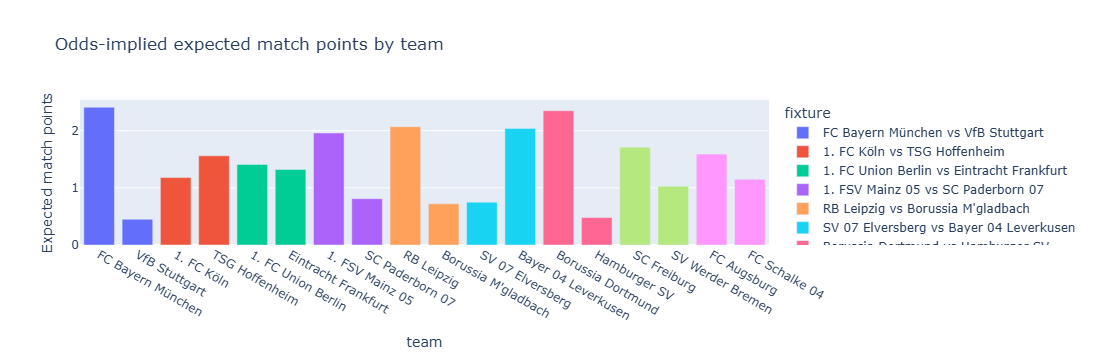

In [5]:
status_rows = [{'artifact': 'Canonical fixtures', 'selected_file': fixtures_path.name, 'state': 'Loaded', 'note': f'{len(fixtures)} fixtures'}]

fotmob_path = FOTMOB_ODDS_DIR / f'matchday_{matchday}_odds_fotmob.json'
sofascore_odds_path = SOFASCORE_ODDS_DIR / f'matchday_{matchday}_odds.json'
fotmob_odds = read_json(fotmob_path) if fotmob_path.is_file() else []
sofascore_odds = read_json(sofascore_odds_path) if sofascore_odds_path.is_file() else []
status_rows.extend([
    {'artifact': 'FotMob odds', 'selected_file': fotmob_path.name if fotmob_path.is_file() else '—', 'state': 'Loaded' if fotmob_path.is_file() else 'Missing', 'note': 'Primary 1X2 source'},
    {'artifact': 'SofaScore odds', 'selected_file': sofascore_odds_path.name if sofascore_odds_path.is_file() else '—', 'state': 'Loaded' if sofascore_odds_path.is_file() else 'Missing', 'note': 'Fallback 1X2 source'},
])

standings_path, standings = newest_json(DERIVED_BUNDESLIGA_SNAPSHOTS_DIR, 'bundesliga_table_*.json')
status_rows.append({'artifact': 'League table', 'selected_file': standings_path.name if standings_path else '—', 'state': 'Loaded' if standings_path else 'Missing', 'note': 'Latest league snapshot; it is not matchday-specific.'})

form_path, form = newest_json(SOFASCORE_TEAM_FORM_DIR, 'team_form_*.json')
status_rows.append({'artifact': 'Recent form', 'selected_file': form_path.name if form_path else '—', 'state': 'Loaded' if form_path else 'Missing', 'note': 'Latest team-form snapshot; it is not matchday-specific.'})

upcoming_path, upcoming = newest_json(SOFASCORE_UPCOMING_MATCHES_DIR, 'upcoming_matches_md_*.json', lambda document, _: isinstance(document, dict) and document.get('requested_matchday') == matchday)
status_rows.append({'artifact': 'Upcoming matches', 'selected_file': upcoming_path.name if upcoming_path else '—', 'state': 'Loaded' if upcoming_path else 'Omitted', 'note': 'Exact requested_matchday match required.'})

ratings_path, ratings = newest_json(SOFASCORE_PLAYER_AVERAGE_RATINGS_DIR, 'team_player_average_ratings_*.json', lambda document, _: form_path is not None and isinstance(document, dict) and document.get('source_file') == form_path.name)
status_rows.append({'artifact': 'SofaScore player ratings', 'selected_file': ratings_path.name if ratings_path else '—', 'state': 'Loaded' if ratings_path else 'Omitted', 'note': 'Must cite the selected form snapshot.'})

lineups = {}
for source_name, directory, pattern in LINEUP_SOURCES:
    path, document, note = matching_lineup_snapshot(directory, pattern, fixture_keys, matchday)
    lineups[source_name] = {'path': path, 'matches': matches_from_snapshot(document) if document else {}, 'note': note}
    status_rows.append({'artifact': f'{source_name} lineups', 'selected_file': path.name if path else '—', 'state': 'Loaded' if path else 'Omitted', 'note': note or 'Exact fixture coverage.'})

overview_rows, fixture_context = [], []
team_points = {}
for fixture in fixtures:
    home, away = fixture['home_team'], fixture['away_team']
    key = fixture_key(home, away)
    selected, source = odds_record(fotmob_odds, key), 'FotMob'
    if selected is None:
        selected, source = odds_record(sofascore_odds, key), 'SofaScore fallback'
    if selected is not None:
        team_points[team_key(home)] = selected['home_points']
        team_points[team_key(away)] = selected['away_points']
    overview_rows.append({'fixture': f'{home} vs {away}', 'odds source': source if selected else 'Unavailable', 'home expected points': round(selected['home_points'], 2) if selected else None, 'away expected points': round(selected['away_points'], 2) if selected else None})
    fixture_context.append({'fixture': fixture, 'key': key, 'odds': selected, 'odds_source': source if selected else 'Unavailable'})

expected_path, expected_players, expected_note = None, None, 'No verified expected-points CSV is available.'
if len(team_points) == 18:
    for candidate in sorted(EXPECTED_POINTS_DIR.glob('expected_points_*.csv'), reverse=True):
        try:
            frame = pd.read_csv(candidate)
            actual = frame.groupby('teamId')['expected_match_points'].first().to_dict()
            comparable = {KB_TEAM_ID_TO_KEY.get(int(team_id)): float(value) for team_id, value in actual.items() if pd.notna(value) and int(team_id) in KB_TEAM_ID_TO_KEY}
        except (OSError, ValueError, KeyError, TypeError):
            continue
        if all(key in comparable and math.isclose(comparable[key], value, abs_tol=1e-6) for key, value in team_points.items()):
            expected_path, expected_players, expected_note = candidate, frame, 'Per-team expected-match points match selected odds.'
            break
status_rows.append({'artifact': 'Player expected points', 'selected_file': expected_path.name if expected_path else '—', 'state': 'Loaded' if expected_path else 'Omitted', 'note': expected_note})

display(Markdown(f'## Matchday {matchday} overview'))
display(pd.DataFrame(status_rows))
overview = pd.DataFrame(overview_rows)
display(overview)
if overview['home expected points'].notna().any():
    expected_overview = pd.concat([
        overview.assign(team=overview['fixture'].str.split(' vs ').str[0], expected_points=overview['home expected points']),
        overview.assign(team=overview['fixture'].str.split(' vs ').str[1], expected_points=overview['away expected points']),
    ])
    display(px.bar(expected_overview.dropna(subset=['expected_points']), x='team', y='expected_points', color='fixture', title='Odds-implied expected match points by team', labels={'expected_points': 'Expected match points'}))


In [6]:
for number, context in enumerate(fixture_context, start=1):
    MATCH_FIGURES = []
    fixture, key, odds = context['fixture'], context['key'], context['odds']
    home, away = fixture['home_team'], fixture['away_team']
    keys = {team_key(home), team_key(away)}
    display(Markdown(f'---\n## {number}. {home} vs {away}'))

    display(Markdown('### 1X2 odds and team expected points'))
    if odds is None:
        display(Markdown('> **Odds unavailable:** no valid FotMob market and no valid SofaScore fallback were saved for this fixture.'))
    else:
        odds_chart = pd.DataFrame([
            {'outcome': home, 'decimal_odds': odds['home_odd']}, {'outcome': 'Draw', 'decimal_odds': odds['draw_odd']}, {'outcome': away, 'decimal_odds': odds['away_odd']},
        ])
        odds_chart['implied_chance'] = 1 / odds_chart['decimal_odds']
        display(Markdown('**Source:** {} — {}'.format(context['odds_source'], odds['bookmaker'])))
        queue_figure(px.bar(odds_chart, x='outcome', y='implied_chance', text='decimal_odds', hover_data={'decimal_odds': ':.2f'}, title='1X2 implied chance (higher means lower odds)', labels={'implied_chance': 'Implied chance', 'decimal_odds': 'Decimal odds'}).update_yaxes(tickformat='.0%'))
        display(pd.DataFrame([{'team': home, 'expected match points': round(odds['home_points'], 3)}, {'team': away, 'expected match points': round(odds['away_points'], 3)}]))

    display(Markdown('### League position'))
    position_rows = standings_rows(standings, keys)
    if position_rows:
        positions = pd.DataFrame(position_rows)
        display(positions)
    else:
        display(Markdown('> League-position snapshot is unavailable for one or both teams.'))

    display(Markdown('### Player expected points'))
    if expected_players is None:
        display(Markdown(f'> **Omitted:** {expected_note}'))
    else:
        player_rows = expected_players[expected_players['teamId'].map(lambda value: KB_TEAM_ID_TO_KEY.get(int(value)) if pd.notna(value) else None).isin(keys)].copy()
        player_rows['team'] = player_rows['teamId'].map(lambda value: KB_TEAM_ID_TO_KEY.get(int(value)) if pd.notna(value) else None)
        team_labels = {team_key(home): home, team_key(away): away}
        player_rows['team_display'] = player_rows['team'].map(team_labels)
        player_rows = player_rows.sort_values(['team_display', 'score'], ascending=[True, False]).groupby('team_display', group_keys=False).head(5)
        queue_figure(px.bar(player_rows.sort_values('score'), x='score', y='name', color='team_display', facet_col='team_display', orientation='h', title='Top five generated player scores for each team', labels={'score': 'Expected-points score', 'team_display': 'Team'}))
        display(player_rows[['name', 'team_display', 'position', 'expected_match_points', 'starting_chance', 'score']])

    display(Markdown('### Recent form and last-five match data'))
    all_form = []
    for name, key_value in ((home, team_key(home)), (away, team_key(away))):
        for category in ('overall', 'bundesliga'):
            all_form.extend(form_rows(form, key_value, category))
    if all_form:
        form_frame = pd.DataFrame(all_form)
        queue_figure(px.scatter(form_frame, x='match_number', y='category', color='result', text='result', facet_row='team', category_orders={'category': ['overall', 'bundesliga']}, color_discrete_map=RESULT_COLOURS, hover_data={'opponent': True, 'score': True, 'date': True, 'competition': True, 'home_team': False, 'away_team': False, 'home_score': False, 'away_score': False}, title='Last five results (oldest to newest)', labels={'match_number': 'Match order', 'category': 'Competition scope', 'opponent': 'Opponent', 'score': 'Score'}, height=420).update_traces(marker_size=18).update_xaxes(dtick=1))
        display(form_frame[['category', 'team', 'date', 'competition', 'home_team', 'home_score', 'away_score', 'away_team', 'result']])
    else:
        display(Markdown('> Recent-form snapshot is unavailable for one or both teams.'))

    display(Markdown('### Upcoming fixtures'))
    next_rows = upcoming_rows(upcoming, team_key(home)) + upcoming_rows(upcoming, team_key(away))
    if next_rows:
        display(pd.DataFrame(next_rows))
    else:
        display(Markdown('> No saved upcoming-match snapshot exactly matches this requested matchday.'))

    display(Markdown('### Best recent SofaScore form'))
    ratings_frame = pd.DataFrame(rating_rows(ratings, keys))
    if not ratings_frame.empty:
        ratings_frame = ratings_frame.sort_values(['category', 'average_rating'], ascending=[True, False]).groupby(['team', 'category'], group_keys=False).head(5)
        ratings_frame['player_label'] = ratings_frame['player_name'] + ' — ' + ratings_frame['category']
        rating_figure = px.bar(ratings_frame.sort_values('average_rating'), x='average_rating', y='player_label', color='category', facet_row='team', orientation='h', hover_data=['position', 'rating_count'], title='Top SofaScore average ratings by team', labels={'average_rating': 'Average rating', 'player_label': 'Player and scope', 'category': 'Scope'}, height=620)
        rating_figure.update_yaxes(showticklabels=True)
        queue_figure(rating_figure)
        display(ratings_frame[['team', 'category', 'player_name', 'position', 'rating_count', 'average_rating']])
    else:
        display(Markdown('> No player-rating snapshot is compatible with the selected form snapshot.'))

    display(Markdown('### Predicted lineups'))
    for source_name, _, _ in LINEUP_SOURCES:
        match = lineups[source_name]['matches'].get(key)
        display(Markdown(f'#### {source_name}'))
        if match is None:
            display(Markdown('> **Omitted:** {}'.format(lineups[source_name]['note'])))
            continue
        for side in ('home', 'away'):
            team = match.get(side, {})
            players = team.get('players', []) if isinstance(team, dict) else []
            starters = [player for player in players if isinstance(player, dict) and player.get('starting_probability_rank', 1) == 1]
            if source_name == 'RotoWire':
                starters = rotowire_coordinates(starters)
            kicker_bench = []
            if source_name == 'Kicker' and isinstance(team, dict):
                raw_bench = team.get('kicker_details', {}).get('bench', {}).get('players', [])
                kicker_bench = [player for player in raw_bench if isinstance(player, dict)] if isinstance(raw_bench, list) else []
            backups = [player for player in players if isinstance(player, dict) and player.get('starting_probability_rank', 1) > 1]
            label = team.get('team_name', side.title()) if isinstance(team, dict) else side.title()
            shape = formation(starters)
            display(Markdown(f'**{label}**' + (f' — formation **{shape}**' if shape else ' — formation not provided')))
            starter_frame = pd.DataFrame(starters)
            has_formation_coordinates = not starter_frame.empty and {'formation_row', 'slot_index'}.issubset(starter_frame.columns) and starter_frame['formation_row'].notna().all() and starter_frame['slot_index'].notna().all()
            if has_formation_coordinates:
                pass
            elif not starter_frame.empty:
                display(starter_frame[[column for column in ('displayed_name', 'full_name', 'position', 'injury_status') if column in starter_frame.columns]])
                display(Markdown('> This provider does not expose formation coordinates.'))
            else:
                display(Markdown('> No predicted starters were saved.'))
            primary_by_slot = {(player.get('formation_row'), player.get('slot_index')): player.get('displayed_name') or player.get('full_name') for player in starters}
            backup_rows = []
            for player in backups:
                alternative_to = primary_by_slot.get((player.get('formation_row'), player.get('slot_index')))
                backup_rows.append({'type': 'Alternative', 'player': player.get('displayed_name') or player.get('full_name'), 'Alternative to': alternative_to or 'Unspecified starter', 'position': player.get('position'), 'injury_status': player.get('injury_status')})
            if source_name == 'Kicker':
                for player in kicker_bench:
                    if isinstance(player, dict):
                        backup_rows.append({'type': 'Bench', 'player': player.get('displayed_name') or player.get('full_name'), 'Alternative to': '—', 'position': player.get('position'), 'injury_status': player.get('injury_status')})
            if has_formation_coordinates:
                queue_figure(formation_figure(starters, source_name, label, backup_rows))
    report_path = open_match_report(matchday, number, f'{home} vs {away}', MATCH_FIGURES)
    if report_path is not None:
        display(Markdown(f'Charts opened in one browser tab: `{report_path}`'))


---
## 1. FC Bayern München vs VfB Stuttgart

### 1X2 odds and team expected points

**Source:** FotMob — Tipico

,team,expected match points
0,FC Bayern München,2.413
1,VfB Stuttgart,0.452


### League position

...

**FC Schalke 04** — formation **3-4-2-1**

#### RotoWire

**FC Augsburg** — formation **3-4-2-1**

**FC Schalke 04** — formation **3-4-2-1**

Charts opened in one browser tab: `C:\Users\sidth\AppData\Local\Temp\kickbase_matchday_reports\matchday_01_09_fc-augsburg-vs-fc-schalke-04.html`